In [1]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

In [3]:
#Leer la base de datos
df = pd.read_excel('DatosRegresion15D.xlsx')

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


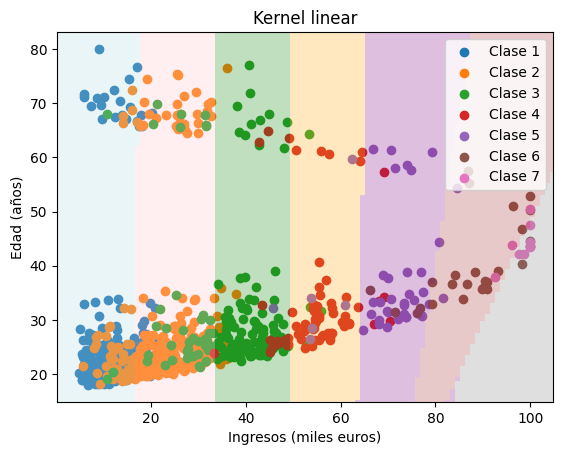

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


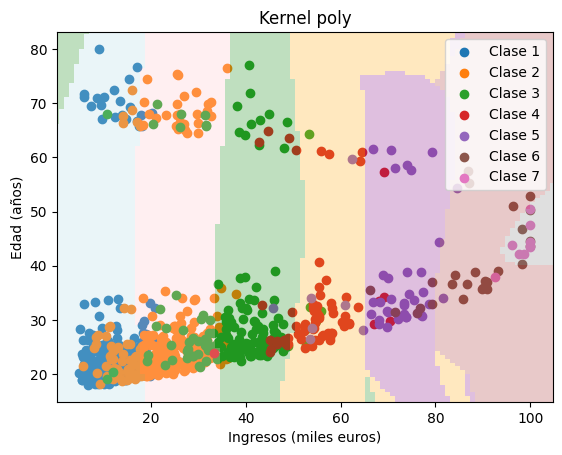

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


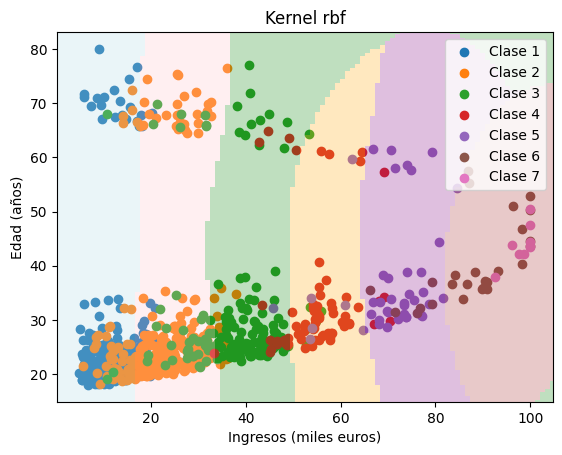

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


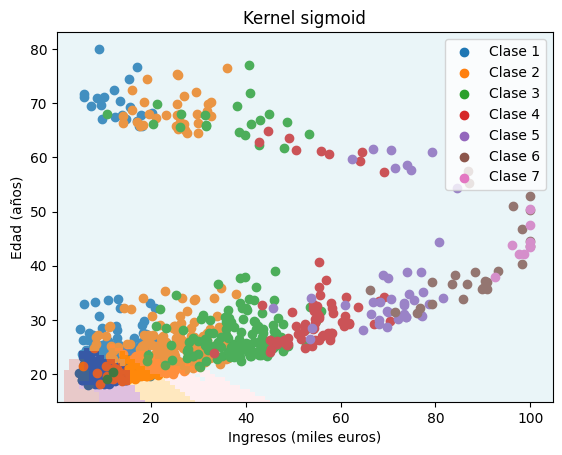

linear
poly
rbf
sigmoid


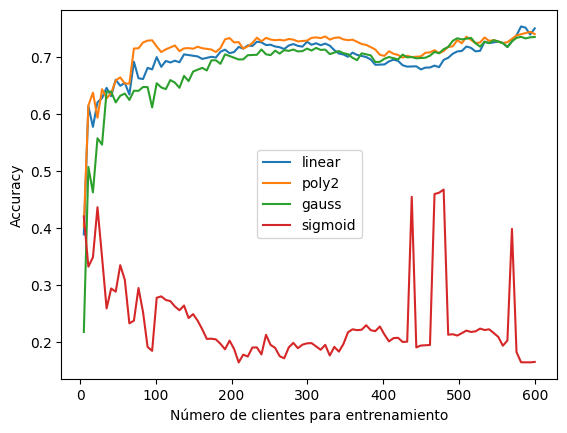

In [4]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase+1}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = OptimizaModelo(X, y, kernel)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, alpha=0.25, edgecolor='none')  # Ajusta la transparencia aquí

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = SVC(gamma='scale', kernel=kernel, degree=4)  # Grado 4 para el kernel polinómico
    modelo.fit(X, y)
    return modelo

def EvaluaModelo(X, y, modelo):
    # X: Características.
    # y: Etiquetas.
    # modelo: Modelo de SVM entrenado.

    ACC = modelo.score(X, y)  # Accuracy (exactitud) del modelo
    return ACC


def DibujaCurvaAprendizaje(X, y):
    # X: Matriz de diseño.
    # y: Vector de objetivos (target).

    npuntos = 100  # Nº de puntos de la curva de aprendizaje
    ntrain_vector = np.linspace(5, 600, npuntos)  # Nº clientes training (vector)
    ACCtest = np.zeros(npuntos)  # Reserva de espacio para el coste de testing
    kernel_vector = ['linear', 'poly', 'rbf', 'sigmoid']  # Agrega 'sigmoid' a la lista de kernels
    orden_vector = [0, 2, 0, 0]  # Ajusta el orden para el kernel sigmoidal
    label_vector = ['linear', 'poly2', 'gauss', 'sigmoid']  # Agrega 'sigmoid' a las etiquetas
    nkernel = len(kernel_vector)

    plt.figure()
    for ikernel in range(nkernel):
        kernel = kernel_vector[ikernel]
        print(kernel)
        orden = orden_vector[ikernel]
        label = label_vector[ikernel]
        for k in range(npuntos):
            # Itera para distintos valores de ntrain
            # Optimiza el modelo para el Training Dataset
            ntrain = ntrain_vector[k]
            ntrain = ntrain.astype('int')  # Lo convierte en un número entero
            Xtrain = X[:ntrain, :]  # Vector de características (training)
            ytrain = y[:ntrain]  # Vector de etiquetas (training)
            modelo = OptimizaModelo(Xtrain, ytrain, kernel)

            # Cálculo del coste para el Test Dataset
            Xtest = X[ntrain:, :]  # Vector de características (test)
            ytest = y[ntrain:]  # Vector de etiquetas (test)
            ACCtest[k] = EvaluaModelo(Xtest, ytest, modelo)  # Coste (test)

        # Dibujo de la curva de aprendizaje
        plt.plot(ntrain_vector, ACCtest, label=label)

    plt.xlabel('Número de clientes para entrenamiento')
    plt.ylabel('Accuracy')
    plt.legend()

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lista de kernels a probar (incluyendo 'sigmoid')
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Genera y muestra las gráficas para cada kernel
for kernel in kernels:
    plt.figure()
    DrawRegionesSVM(X_train, y_train, kernel)
    plt.title(f'Kernel {kernel}')
    plt.show()

# Muestra la curva de aprendizaje
DibujaCurvaAprendizaje(X_train, y_train)
plt.show()


<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


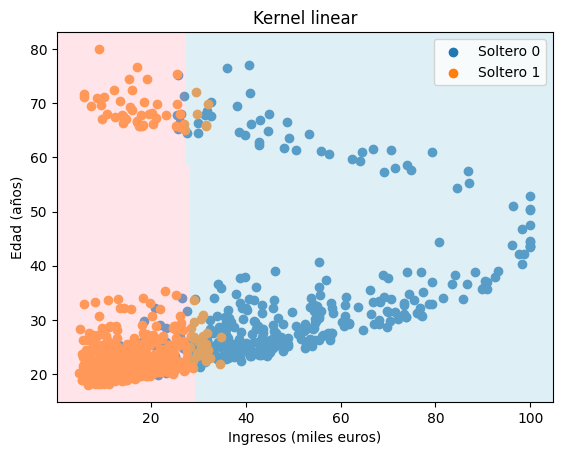

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


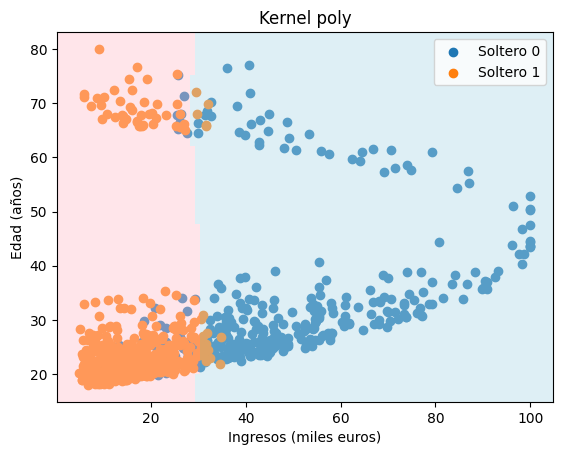

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


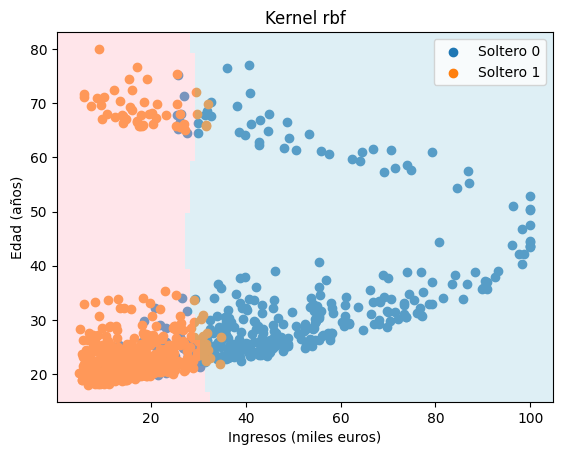

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


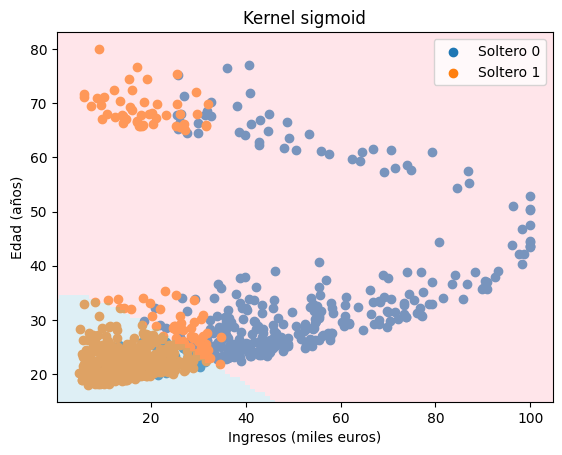

linear
poly
rbf
sigmoid


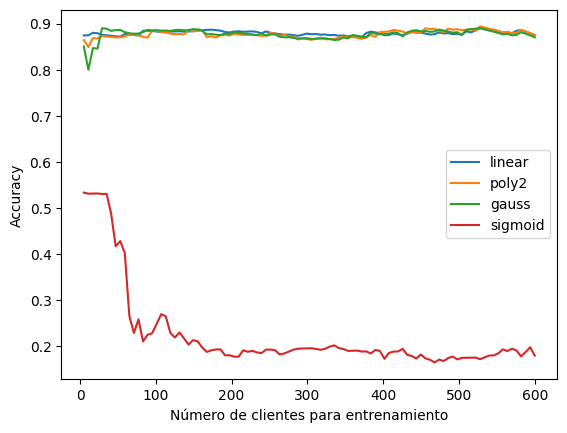

In [5]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Soltero {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel):
    modelo = OptimizaModelo(X, y, kernel)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, alpha=0.4, edgecolor='none')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel):
    modelo = SVC(gamma='scale', kernel=kernel, degree=4)
    modelo.fit(X, y)
    return modelo

def EvaluaModelo(X, y, modelo):
    ACC = modelo.score(X, y)
    return ACC

def DibujaCurvaAprendizaje(X, y):
    npuntos = 100
    ntrain_vector = np.linspace(5, 600, npuntos)
    ACCtest = np.zeros(npuntos)
    kernel_vector = ['linear', 'poly', 'rbf', 'sigmoid']
    orden_vector = [0, 2, 0, 0]
    label_vector = ['linear', 'poly2', 'gauss', 'sigmoid']
    nkernel = len(kernel_vector)

    plt.figure()
    for ikernel in range(nkernel):
        kernel = kernel_vector[ikernel]
        print(kernel)
        orden = orden_vector[ikernel]
        label = label_vector[ikernel]
        for k in range(npuntos):
            ntrain = ntrain_vector[k]
            ntrain = ntrain.astype('int')
            Xtrain = X[:ntrain, :]
            ytrain = y[:ntrain]
            modelo = OptimizaModelo(Xtrain, ytrain, kernel)
            Xtest = X[ntrain:, :]
            ytest = y[ntrain:]
            ACCtest[k] = EvaluaModelo(Xtest, ytest, modelo)

        plt.plot(ntrain_vector, ACCtest, label=label)

    plt.xlabel('Número de clientes para entrenamiento')
    plt.ylabel('Accuracy')
    plt.legend()

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Características para la clasificación
X = df[['ingresos', 'edad']].values
y = df['soltero'].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lista de kernels a probar (incluyendo 'sigmoid')
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Genera y muestra las gráficas para cada kernel
for kernel in kernels:
    plt.figure()
    DrawRegionesSVM(X_train, y_train, kernel)
    plt.title(f'Kernel {kernel}')
    plt.show()

# Muestra la curva de aprendizaje
DibujaCurvaAprendizaje(X_train, y_train)
plt.show()
